# Unit 7.4: Training Convolutional Neural Networks

## Part 4 of 5: Implementing a ResNet From Scratch

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torchmetrics
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter

torch.manual_seed(123)

In [3]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_full   = torchvision.datasets.CIFAR10(root="data/", train=True,  download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root="data/", train=False, download=True, transform=transform)

train_dataset, val_dataset = random_split(
    train_full,
    [45000, 5000],
    generator=torch.Generator().manual_seed(123)
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

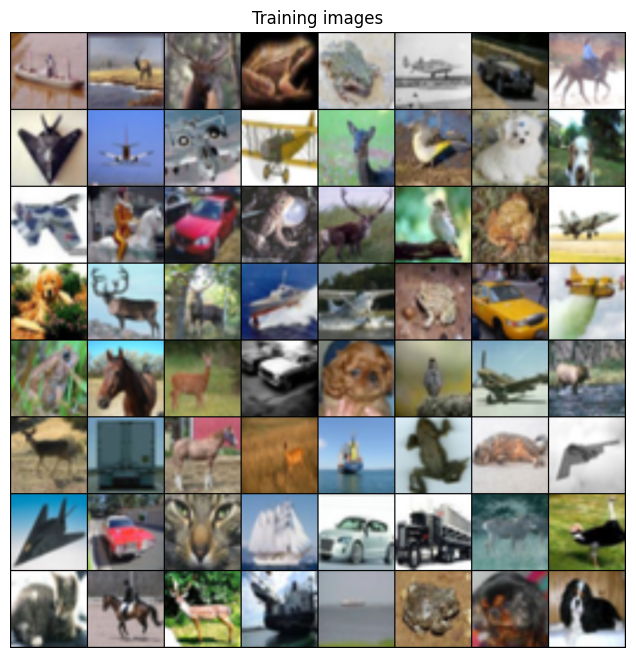

In [4]:
for images, labels in train_loader:  
    break

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training images")
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:64], 
    padding=2,
    normalize=True),
    (1, 2, 0)))
plt.show()

In [5]:
##########################
### MODEL
##########################


def conv3x3(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out


class PyTorchResNet18(nn.Module):

    def __init__(self, block, layers, num_classes, grayscale):
        super().__init__()
        
        if grayscale:
            in_dim = 1
        else:
            in_dim = 3
        self.inplanes = 64
        self.conv1 = nn.Conv2d(in_dim, 64, kernel_size=7, stride=2, padding=3,
                               bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, (2. / n)**.5)
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, start_dim=1)
        logits = self.fc(x)
        probas = F.softmax(logits, dim=1)
        return logits



def make_pytorch_resnet18(num_classes, grayscale=False):
    """Constructs a ResNet-18 model."""
    model = PyTorchResNet18(block=BasicBlock, 
                            layers=[2, 2, 2, 2],
                            num_classes=num_classes,
                            grayscale=grayscale)
    return model

In [9]:
def train_one_epoch(model, loader, optimizer, criterion, acc_metric, device):
    model.train()
    acc_metric.reset()
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        acc_metric.update(logits, labels)

    return total_loss / len(loader.dataset), acc_metric.compute().item()

In [6]:
def evaluate(model, loader, criterion, acc_metric, device):
    model.eval()
    acc_metric.reset()
    total_loss = 0.0

    with torch.inference_mode():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            total_loss += criterion(logits, labels).item() * labels.size(0)
            acc_metric.update(logits, labels)

    return total_loss / len(loader.dataset), acc_metric.compute().item()

In [7]:
torch.manual_seed(123)
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = make_pytorch_resnet18(num_classes=10).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
val_acc   = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

writer = SummaryWriter(log_dir="logs/resnet18-cifar10")

dummy = torch.zeros(1, 3, 128, 128).to(device)
writer.add_graph(model, dummy)

In [ ]:
MAX_EPOCHS = 50

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, train_acc, device)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, val_acc, device)

    writer.add_scalars("Loss",     {"train": tr_loss, "val": vl_loss}, epoch)
    writer.add_scalars("Accuracy", {"train": tr_acc,  "val": vl_acc},  epoch)

    print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

writer.close()

Epoch 01/50 | Train Loss: 1.8307  Acc: 0.3425 | Val Loss: 1.5277  Acc: 0.4448
Epoch 02/50 | Train Loss: 1.1951  Acc: 0.5704 | Val Loss: 1.1474  Acc: 0.5936
Epoch 03/50 | Train Loss: 0.9205  Acc: 0.6744 | Val Loss: 0.8727  Acc: 0.6820
Epoch 04/50 | Train Loss: 0.7307  Acc: 0.7441 | Val Loss: 0.7842  Acc: 0.7294
Epoch 05/50 | Train Loss: 0.5919  Acc: 0.7910 | Val Loss: 0.6959  Acc: 0.7608
Epoch 06/50 | Train Loss: 0.4784  Acc: 0.8308 | Val Loss: 0.7091  Acc: 0.7638
Epoch 07/50 | Train Loss: 0.3914  Acc: 0.8620 | Val Loss: 0.6875  Acc: 0.7744
Epoch 08/50 | Train Loss: 0.3086  Acc: 0.8908 | Val Loss: 0.7203  Acc: 0.7766
Epoch 09/50 | Train Loss: 0.2545  Acc: 0.9097 | Val Loss: 0.7360  Acc: 0.7818
Epoch 10/50 | Train Loss: 0.2111  Acc: 0.9258 | Val Loss: 0.9187  Acc: 0.7416
Epoch 11/50 | Train Loss: 0.1865  Acc: 0.9346 | Val Loss: 0.7536  Acc: 0.7858
Epoch 12/50 | Train Loss: 0.1478  Acc: 0.9478 | Val Loss: 0.8045  Acc: 0.7752
Epoch 13/50 | Train Loss: 0.1359  Acc: 0.9521 | Val Loss: 0.7268